In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.data.cvDataset import Dataset
from src.config import Config

In [2]:
def load_raw_data(dir: str) -> list[pd.DataFrame]:
    """Loads raw data from the specified directory.

    Args:
        dir (str): Directory containing the raw data files.

    Returns:
        list[pd.DataFrame]: List of DataFrames containing the raw data.
    """
    
    files = [f for f in os.listdir(dir) if f.endswith('.csv')]
    data = []
    for file in files:
        df = pd.read_csv(os.path.join(dir, file))
        data.append(df)
    return data

def load_train_data(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    """Loads and concatenates training data from a list of DataFrames.

    Args:
        dfs (list[pd.DataFrame]): List of DataFrames containing training data.

    Returns:
        pd.DataFrame: Concatenated DataFrame of training data.
    """
    train_data = pd.concat(dfs, ignore_index=True)
    
    return train_data

In [3]:
train = load_raw_data("../data/external/BOX/train")
test = load_raw_data("../data/external/BOX/test")[0]
train = load_train_data(train)

In [4]:
train.describe()

,rssi,seqno,s1x,s1y,s1z,s2x,s2y,s2z,s3x,s3y,s3z,s4x,s4y,s4z,s5x,s5y,s5z
count,56098.000000,5.609800e+04,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000,56098.000000
mean,-74.977735,8.717630e+06,0.229477,0.178149,0.340792,0.229655,0.179068,0.341019,0.229839,0.178249,0.340907,0.229068,0.179084,0.341138,0.229299,0.178394,0.341528
std,14.655083,4.065406e+06,0.529307,0.482494,0.521702,0.529704,0.482951,0.521849,0.529781,0.483418,0.521047,0.529632,0.484830,0.521764,0.529857,0.483082,0.520945
min,-107.000000,4.085140e+05,-1.875000,-2.031250,-1.468750,-2.812500,-2.906250,-2.125000,-1.531250,-3.718750,-2.062500,-1.906250,-2.031250,-3.000000,-1.625000,-2.875000,-1.718750
25%,-86.000000,8.932251e+06,-0.156250,-0.156250,-0.031250,-0.156250,-0.156250,-0.031250,-0.156250,-0.156250,-0.031250,-0.156250,-0.156250,-0.031250,-0.156250,-0.156250,-0.031250
50%,-77.000000,1.139434e+07,0.093750,0.218750,0.312500,0.093750,0.218750,0.312500,0.093750,0.218750,0.312500,0.093750,0.218750,0.312500,0.093750,0.218750,0.312500
75%,-66.000000,1.144913e+07,0.843750,0.562500,0.843750,0.843750,0.562500,0.843750,0.843750,0.562500,0.843750,0.843750,0.562500,0.843750,0.843750,0.562500,0.843750
max,-1.000000,1.147480e+07,3.781250,2.625000,3.968750,3.218750,3.281250,3.562500,2.781250,2.531250,3.500000,2.437500,3.968750,3.968750,2.687500,2.437500,3.437500


In [5]:
test.describe()

,rssi,seqno,s1x,s1y,s1z,s2x,s2y,s2z,s3x,s3y,s3z,s4x,s4y,s4z,s5x,s5y,s5z
count,37409.000000,3.740900e+04,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000,37409.000000
mean,-76.785426,4.222471e+06,0.219838,0.365412,0.478961,0.219268,0.365408,0.479743,0.219335,0.366083,0.479790,0.219617,0.367453,0.479449,0.219967,0.366794,0.478721
std,11.794576,2.762011e+04,0.597868,0.309147,0.398452,0.597638,0.307550,0.397083,0.598175,0.304520,0.397094,0.598031,0.305063,0.396939,0.598342,0.306457,0.399553
min,-107.000000,4.168334e+06,-2.281250,-4.000000,-2.843750,-1.843750,-4.000000,-2.375000,-1.468750,-1.281250,-3.562500,-1.406250,-2.187500,-2.375000,-1.406250,-2.593750,-2.562500
25%,-85.000000,4.202274e+06,-0.281250,0.187500,0.187500,-0.281250,0.187500,0.187500,-0.281250,0.187500,0.187500,-0.281250,0.187500,0.187500,-0.281250,0.187500,0.187500
50%,-77.000000,4.228781e+06,0.218750,0.375000,0.500000,0.218750,0.375000,0.500000,0.218750,0.375000,0.500000,0.218750,0.375000,0.500000,0.218750,0.375000,0.500000
75%,-69.000000,4.251525e+06,0.781250,0.562500,0.875000,0.781250,0.562500,0.875000,0.781250,0.562500,0.875000,0.781250,0.562500,0.875000,0.781250,0.562500,0.875000
max,-33.000000,4.262404e+06,2.250000,2.812500,1.968750,2.187500,3.968750,3.187500,2.625000,3.968750,2.468750,2.250000,3.968750,2.375000,2.062500,3.968750,2.593750


In [6]:
def expand_acc(df: pd.DataFrame, gateways: list[str], acc_samples: list[str]) -> pd.DataFrame:
    """Expands the 5 accelerometer samples into separate rows, interpolating RSSI values based on timestamps.

    Args:
        df (pd.DataFrame): The input DataFrame.
        gateways (list[str]): List of gateway column names.
        acc_samples (list[str]): List of accelerometer sample column names.

    Returns:
        pd.DataFrame: DataFrame with expanded accelerometer samples.
    """
    axes = ['x', 'y', 'z']
    
    # Slice arrays for setup 
    rssi_now = df[gateways].iloc[:-1].to_numpy()
    
    # Align targets to next row (end of window later)
    seqnos = df['seqno'].iloc[:-1].to_numpy()
    targets = df['true_room'].iloc[:-1].to_numpy()
    
    # # Linearly interpolate RSSI values between samples
    rssi_expanded = np.repeat(rssi_now[:, None, :], 5, axis=1)
    
    # Reshape accelerometer data
    acc_raw = df[acc_samples].to_numpy().reshape(-1, 5 , 3)
    # Keep all but last row
    acc_df = acc_raw[:-1]
    
    # Create final dataframe with interpolated RSSI values
    out = pd.DataFrame({
        'seqno': np.repeat(seqnos, 5),
        'sample': np.tile(np.arange(1, 6), len(df) - 1),
        'true_room': np.repeat(targets, 5),
        **{gateway: rssi_expanded[:, :, i].flatten() for i, gateway in enumerate(gateways)},
        **{f'a{axis}': acc_df[:, :, j].flatten() for j, axis in enumerate(axes)}
    })

    for gateway in gateways:
        # Interpolate NaN values in RSSI columns
        out[gateway] = out[gateway].interpolate(method='linear', limit_direction='both')
        # Forward/backward fill NaN values
        out[gateway] = out[gateway].ffill().bfill()
    
    return out

def restructure_data(df: pd.DataFrame, acc_samples: list[str]) -> pd.DataFrame:
        """Restructures the DataFrame for model input.

        Args:
            df (pd.DataFrame): Input DataFrame.

        Returns:
            pd.DataFrame: Restructured DataFrame.
        """
        df = df.copy()

        # Pivot the RSSI values for each gateway, fill na with -105 (~min RSSI)
        rssi = df.pivot_table(index='seqno', columns='gateway', values='rssi', aggfunc='first')
        # Group by 'seqno' and flatten the accelerometer, true_room and timestamp cols
        acc = df.groupby('seqno')[acc_samples + ['true_room', 'timestamp']].first()
        # Join the dataset back together
        final_df = acc.join(rssi).reset_index()

        return final_df

In [7]:
acc_samples = [f's{i}{axis}' for i in range(1, 6) for axis in ['x', 'y', 'z']]
gateways = ['bedroom', 'kitchen', 'living', 'stairs']

splits = {"train": train, "test": test}
splits = {key: restructure_data(split, acc_samples) for key, split in splits.items()}
splits = {key: expand_acc(split, gateways, acc_samples) for key, split in splits.items()}

In [8]:
splits['train'].describe()

,seqno,sample,bedroom,kitchen,living,stairs,ax,ay,az
count,1.559350e+05,155935.000000,155935.000000,155935.000000,155935.000000,155935.000000,155935.000000,155935.000000,155935.000000
mean,8.547751e+06,3.000000,-78.414163,-72.370539,-82.339340,-80.840398,0.264476,0.169264,0.311562
std,4.211461e+06,1.414218,13.719461,18.824274,11.929326,14.978943,0.536836,0.484310,0.519594
min,4.085140e+05,1.000000,-105.000000,-105.000000,-107.000000,-105.000000,-2.812500,-3.718750,-3.000000
25%,8.931219e+06,2.000000,-87.752583,-88.658659,-90.142857,-90.462748,-0.156250,-0.187500,-0.062500
50%,1.139353e+07,3.000000,-81.698758,-74.541943,-85.000000,-85.000000,0.156250,0.218750,0.250000
75%,1.144892e+07,4.000000,-71.342287,-58.809772,-75.000000,-76.500000,0.875000,0.531250,0.812500
max,1.147480e+07,5.000000,-6.000000,-12.000000,-15.000000,-1.000000,3.781250,3.968750,3.968750


In [9]:
splits['test'].describe()

,seqno,sample,bedroom,kitchen,living,stairs,ax,ay,az
count,1.164600e+05,116460.00000,116460.000000,116460.000000,116460.000000,116460.000000,116460.000000,116460.000000,116460.000000
mean,4.223237e+06,3.00000,-80.177679,-81.937554,-81.821398,-87.408037,0.241139,0.389303,0.469282
std,2.648282e+04,1.41422,8.642779,12.111371,10.846415,9.170819,0.578540,0.307452,0.403681
min,4.168334e+06,1.00000,-105.000000,-106.000000,-105.000000,-107.000000,-2.281250,-4.000000,-3.562500
25%,4.203815e+06,2.00000,-86.000000,-91.129165,-89.958721,-93.363636,-0.281250,0.218750,0.187500
50%,4.229484e+06,3.00000,-81.486146,-85.783416,-85.002222,-88.153846,0.250000,0.375000,0.500000
75%,4.250763e+06,4.00000,-75.500000,-73.000000,-74.000000,-84.255436,0.781250,0.593750,0.875000
max,4.262402e+06,5.00000,-40.000000,-41.000000,-40.000000,-33.000000,2.625000,3.968750,3.187500


In [10]:
splits['test']['true_room'].value_counts()

true_room
livingroom    49605
kitchen       42190
bedroom       15325
stairs         9340
Name: count, dtype: int64

In [11]:
splits['train']['true_room'].value_counts()

true_room
livingroom    40850
bedroom       38950
stairs        38705
kitchen       37430
Name: count, dtype: int64

In [12]:
splits = {"train": train, "test": test}
config = Config()
dataset = Dataset(config.random_seed)
splits = dataset.data_pipeline(splits)

In [17]:
train_distribution = pd.Series(splits['train']['y']).value_counts()
test_distribution = pd.Series(splits['test']['y']).value_counts()
print(len(splits['train']['y']), "train samples")
print(len(splits['test']['y']), "test samples")
print("Train Distribution:\n", train_distribution, "\n")
print("Test Distribution:\n", test_distribution)

1430 train samples
1037 test samples
Train Distribution:
 livingroom    380
bedroom       356
kitchen       349
stairs        345
Name: count, dtype: int64 

Test Distribution:
 livingroom    464
kitchen       392
bedroom       128
stairs         53
Name: count, dtype: int64


In [14]:
def plot_split_distribution(counts: pd.Series, title: str):
    """Plots the distribution of room types in a given split.

    Args:
        counts (pd.Series): Series containing counts of each room type.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, palette=sns.color_palette("flare", len(counts)))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type='center', color='white')
    plt.title(title)
    plt.xlabel('Room Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.savefig(f"../reports/figures/{title.lower().replace(' ', '_')}.png")

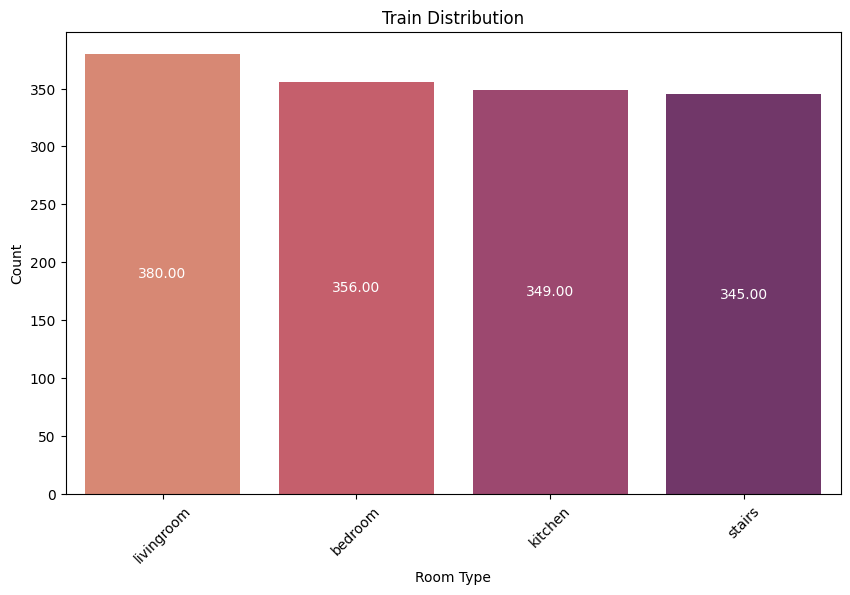

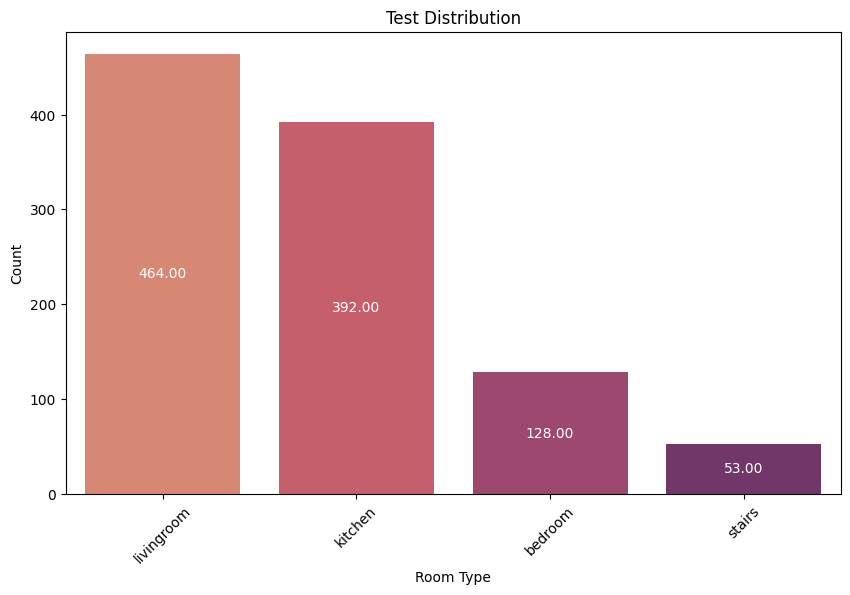

In [15]:
plot_split_distribution(train_distribution, "Train Distribution")
plot_split_distribution(test_distribution, "Test Distribution")